In [7]:
import pandas as pd

# Paste exactly what you copied here, just add the 'r' in front:
historical_path = r"C:\Users\Administrator\Downloads\historical_data.csv"
sentiment_path = r"C:\Users\Administrator\Downloads\fear_greed_index.csv"

# Load the data
df_historical = pd.read_csv(historical_path)
df_sentiment = pd.read_csv(sentiment_path)

print("Data loaded successfully!")
print(df_historical.head(2))

Data loaded successfully!
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec09451986a1874e3a980418412fcd0201f500c95bac...  52017706630   
1         0.0  0xec09451986a1874e3a980418412fcd0201f500c95bac...  52017706630   

   Crossed       Fee      Trade ID     Timestamp  
0     True  0.345404  8.950000e+14  1.730000e+12  
1     True  0.005600  4.430000e+14  1.730000e+12  


In [8]:
import pandas as pd

# 1. Convert 'Timestamp IST' to a standard datetime format
df_historical['Cleaned_DateTime'] = pd.to_datetime(df_historical['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce')

# 2. Extract just the Date (YYYY-MM-DD) for merging
df_historical['Merge_Date'] = df_historical['Cleaned_DateTime'].dt.date

# 3. Ensure the sentiment date column is also a date object
df_sentiment['Merge_Date'] = pd.to_datetime(df_sentiment['date']).dt.date

# 4. Merge both datasets on the common Date column
df_merged = pd.merge(df_historical, df_sentiment, on='Merge_Date', how='inner')

# 5. Check the result
print("--- Datasets Merged Successfully! ---")
print(f"Combined Shape: {df_merged.shape}")
print("\nQuick look at combined data:")
print(df_merged[['Merge_Date', 'Closed PnL', 'classification', 'value']].head(5))

--- Datasets Merged Successfully! ---
Combined Shape: (211218, 22)

Quick look at combined data:
   Merge_Date  Closed PnL classification  value
0  2024-12-02         0.0  Extreme Greed     80
1  2024-12-02         0.0  Extreme Greed     80
2  2024-12-02         0.0  Extreme Greed     80
3  2024-12-02         0.0  Extreme Greed     80
4  2024-12-02         0.0  Extreme Greed     80


--- Performance Metrics by Market Sentiment ---
classification    Total_PnL  Average_PnL  Average_Trade_Size  Total_Trades  Win_Rate
  Extreme Fear 7.391102e+05    34.537862         5349.731843         21400 37.060748
 Extreme Greed 2.715171e+06    67.892861         3112.251565         39992 46.494299
          Fear 3.357155e+06    54.290400         7816.109931         61837 42.076750
         Greed 2.150129e+06    42.743559         5736.884375         50303 38.482794
       Neutral 1.292921e+06    34.307718         4782.732661         37686 39.699093


C:\Users\Administrator\AppData\Local\Temp\ipykernel_9276\1471749972.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0,0], data=sentiment_stats, x='classification', y='Average_PnL', palette='coolwarm')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_9276\1471749972.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0,1], data=sentiment_stats, x='classification', y='Win_Rate', palette='viridis')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_9276\1471749972.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax

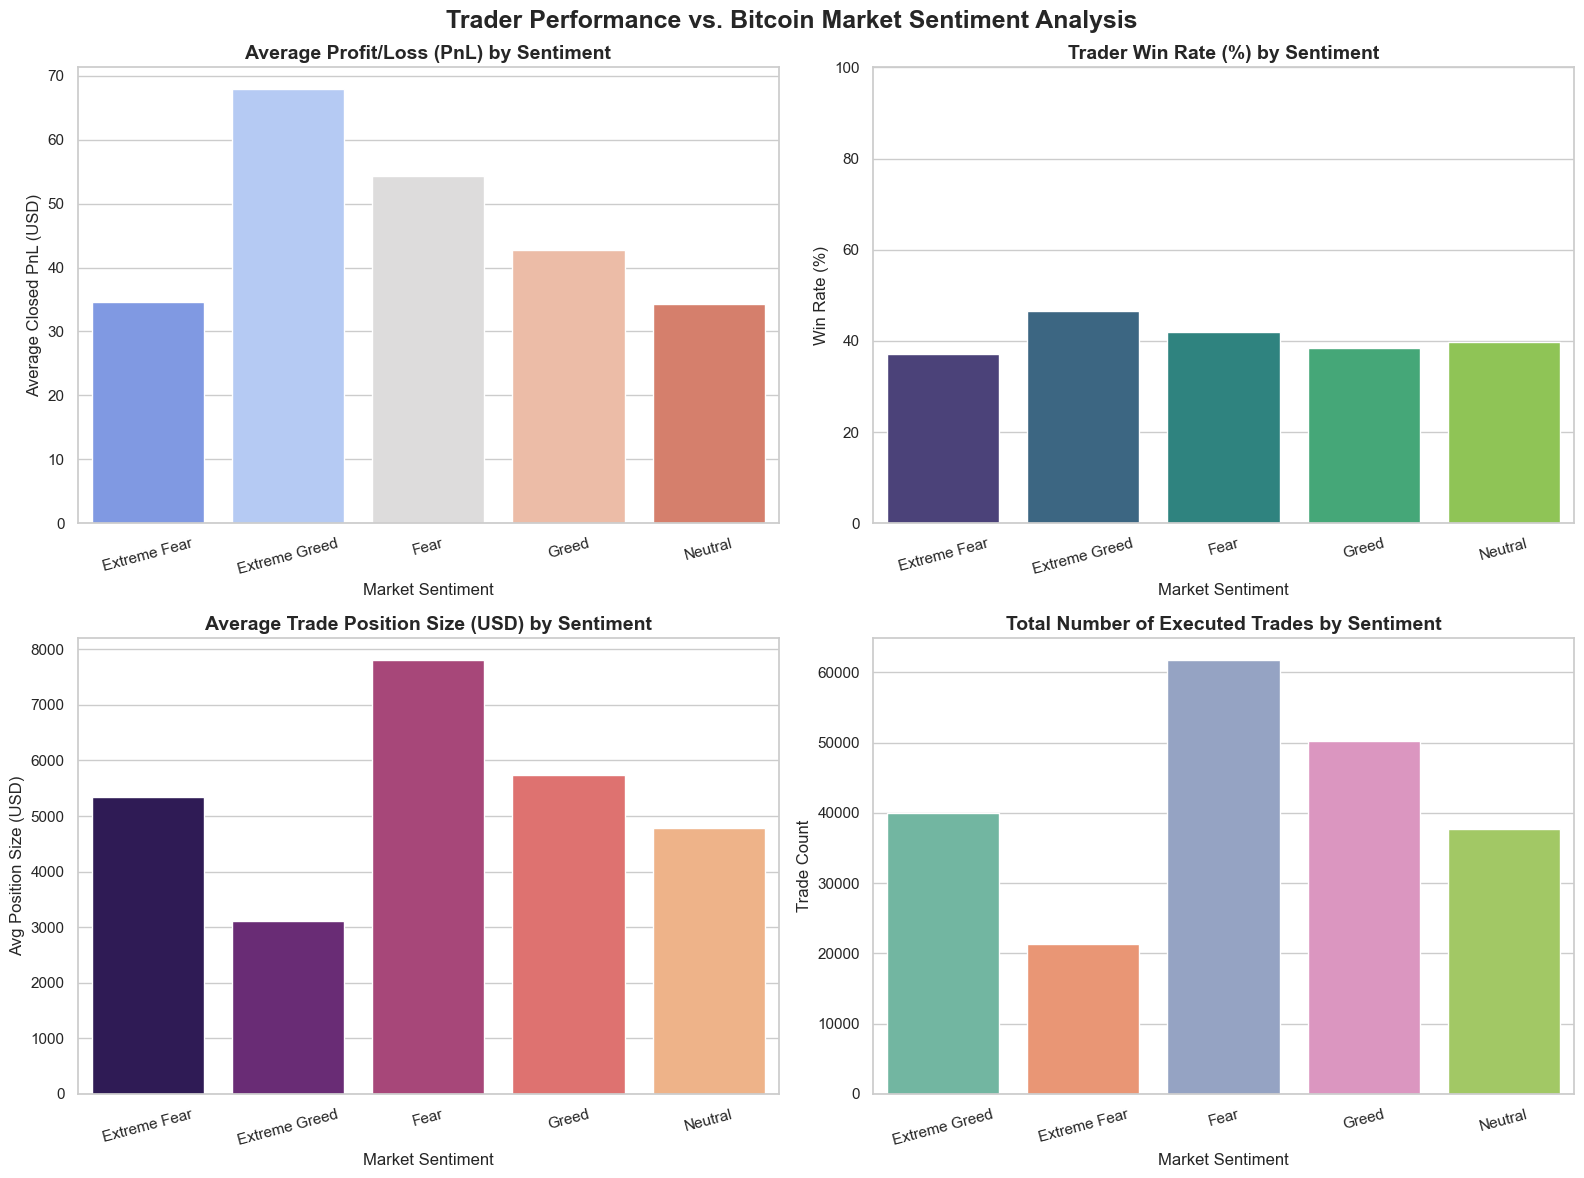

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean plot style
sns.set_theme(style="whitegrid")

# 1. Basic Performance Metrics by Sentiment Classification
# We calculate total PnL, average PnL, count of trades, and win rate
df_merged['Is_Profit'] = df_merged['Closed PnL'] > 0

sentiment_stats = df_merged.groupby('classification').agg(
    Total_PnL=('Closed PnL', 'sum'),
    Average_PnL=('Closed PnL', 'mean'),
    Average_Trade_Size=('Size USD', 'mean'),
    Total_Trades=('Closed PnL', 'count'),
    Win_Rate=('Is_Profit', lambda x: (x.sum() / len(x)) * 100)
).reset_index()

print("--- Performance Metrics by Market Sentiment ---")
print(sentiment_stats.to_string(index=False))

# 2. Plotting the Insights
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Trader Performance vs. Bitcoin Market Sentiment Analysis', fontsize=18, fontweight='bold')

# Chart A: Average PnL per Sentiment Category
sns.barplot(ax=axes[0,0], data=sentiment_stats, x='classification', y='Average_PnL', palette='coolwarm')
axes[0,0].set_title('Average Profit/Loss (PnL) by Sentiment', fontsize=14, fontweight='semibold')
axes[0,0].set_xlabel('Market Sentiment')
axes[0,0].set_ylabel('Average Closed PnL (USD)')
axes[0,0].tick_params(axis='x', rotation=15)

# Chart B: Win Rate Percentage by Sentiment Category
sns.barplot(ax=axes[0,1], data=sentiment_stats, x='classification', y='Win_Rate', palette='viridis')
axes[0,1].set_title('Trader Win Rate (%) by Sentiment', fontsize=14, fontweight='semibold')
axes[0,1].set_xlabel('Market Sentiment')
axes[0,1].set_ylabel('Win Rate (%)')
axes[0,1].set_ylim(0, 100)
axes[0,1].tick_params(axis='x', rotation=15)

# Chart C: Average Trade Size by Sentiment Category (Risk Appetite)
sns.barplot(ax=axes[1,0], data=sentiment_stats, x='classification', y='Average_Trade_Size', palette='magma')
axes[1,0].set_title('Average Trade Position Size (USD) by Sentiment', fontsize=14, fontweight='semibold')
axes[1,0].set_xlabel('Market Sentiment')
axes[1,0].set_ylabel('Avg Position Size (USD)')
axes[1,0].tick_params(axis='x', rotation=15)

# Chart D: Distribution of Trades across Sentiment Categories
sns.countplot(ax=axes[1,1], data=df_merged, x='classification', palette='Set2')
axes[1,1].set_title('Total Number of Executed Trades by Sentiment', fontsize=14, fontweight='semibold')
axes[1,1].set_xlabel('Market Sentiment')
axes[1,1].set_ylabel('Trade Count')
axes[1,1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [10]:
# Grouping by Sentiment AND Trade Direction to see who wins where
direction_stats = df_merged.groupby(['classification', 'Direction']).agg(
    Avg_PnL=('Closed PnL', 'mean'),
    Total_Trades=('Closed PnL', 'count'),
    Win_Rate=('Is_Profit', lambda x: (x.sum() / len(x)) * 100)
).reset_index()

print("--- Directional Strategy Performance ---")
print(direction_stats.sort_values(by=['classification', 'Avg_PnL'], ascending=[True, False]).to_string(index=False))

--- Directional Strategy Performance ---
classification                 Direction       Avg_PnL  Total_Trades   Win_Rate
  Extreme Fear               Close Short    123.400238          3117  70.580687
  Extreme Fear                Close Long     81.197371          6241  84.649896
  Extreme Fear              Long > Short      1.331956             5 100.000000
  Extreme Fear                       Buy      0.000000           807   0.000000
  Extreme Fear                 Open Long      0.000000          7005   0.000000
  Extreme Fear                Open Short      0.000000          3174   0.000000
  Extreme Fear      Spot Dust Conversion      0.000000             3   0.000000
  Extreme Fear                      Sell   -135.021730          1042  42.034549
  Extreme Fear              Short > Long  -1932.516940             6  83.333333
 Extreme Greed                      Sell    290.572354          7164  92.434394
 Extreme Greed              Long > Short    120.600968             7  85.714286

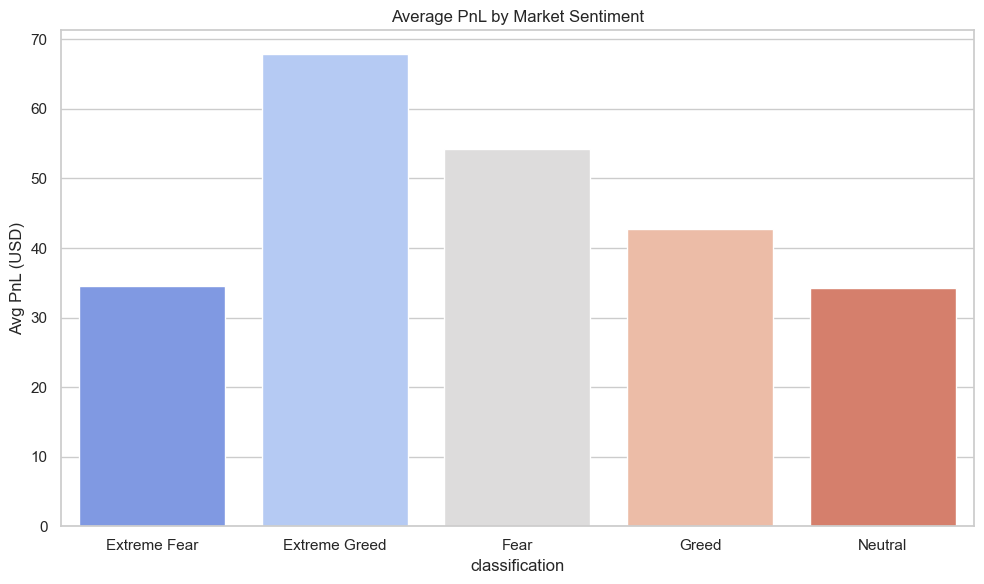

In [12]:
# analysis.py or notebook cell
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df_historical = pd.read_csv(r'C:\Users\Administrator\Downloads\historical_data.csv')
df_sentiment = pd.read_csv(r'C:\Users\Administrator\Downloads\fear_greed_index.csv')

# 2. Clean & Merge
df_historical['Cleaned_DateTime'] = pd.to_datetime(df_historical['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce')
df_historical['Merge_Date'] = df_historical['Cleaned_DateTime'].dt.date
df_sentiment['Merge_Date'] = pd.to_datetime(df_sentiment['date']).dt.date
df_merged = pd.merge(df_historical, df_sentiment, on='Merge_Date', how='inner')

# 3. Compute Metrics
df_merged['Is_Profit'] = df_merged['Closed PnL'] > 0
sentiment_stats = df_merged.groupby('classification').agg(
    Total_PnL=('Closed PnL', 'sum'),
    Average_PnL=('Closed PnL', 'mean'),
    Average_Trade_Size=('Size USD', 'mean'),
    Total_Trades=('Closed PnL', 'count'),
    Win_Rate=('Is_Profit', lambda x: (x.sum() / len(x)) * 100)
).reset_index()

# 4. Save Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=sentiment_stats, x='classification', y='Average_PnL', hue='classification', legend=False, palette='coolwarm')
plt.title('Average PnL by Market Sentiment')
plt.ylabel('Avg PnL (USD)')
plt.tight_layout()
plt.savefig('sentiment_performance.png')
plt.show()